# 04 Threshold Tuning And Rules

## 목표
- baseline score를 운영 가능한 경보 규칙으로 다듬는다.
- validation 구간에서 threshold와 cooldown rule을 튜닝한다.
- `balanced`와 `conservative` 두 가지 운영안을 고르고 test에서 검증한다.

In [1]:
import os
from pathlib import Path
import warnings

# 노트북 재실행 시에도 같은 위치에서 결과가 쌓이도록 경로를 고정한다.
PROJECT_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects")
DATA_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data")
OUTPUT_DIR = PROJECT_DIR / "outputs" / "04_threshold_tuning_and_rules"
MPLCONFIG_DIR = PROJECT_DIR / ".mplconfig"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")

RAW_PATH = DATA_DIR / "sub_upbit_eth_min_tick.csv"
FEAT_PATH = DATA_DIR / "sub_upbit_eth_min_feature_labels.pkl"

print(f"RAW_PATH exists: {RAW_PATH.exists()}")
print(f"FEAT_PATH exists: {FEAT_PATH.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


RAW_PATH exists: True
FEAT_PATH exists: True
OUTPUT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects/outputs/04_threshold_tuning_and_rules


### 결과 해석
- 모델 튜닝 결과가 다른 노트북 산출물과 섞이지 않도록 별도 출력 폴더를 만들었습니다. 이후 validation grid, 선택된 규칙, test 비교표가 모두 이 폴더 아래에 저장됩니다.
- 문제는 노트북 환경에서 경로/시각화 캐시가 세션마다 흔들릴 수 있다는 점인데, 원인은 기본 캐시 경로의 쓰기 권한 이슈입니다. 프로젝트 내부에 설정 폴더를 따로 두어 실행 안정성을 확보했습니다.


## 1. 튜닝용 데이터셋과 score 준비

이 단계에서는 `fit_train / valid / test` 3구간으로 나누고, validation 튜닝에 쓸 score와 pseudo event label을 준비합니다.


In [2]:
# raw 데이터에서 anomaly 판단에 직접 쓸 파생변수를 다시 계산한다.
raw = pd.read_csv(RAW_PATH, parse_dates=["time"]).sort_values("time").reset_index(drop=True)
raw["ret_1"] = raw["close"].pct_change()
raw["log_ret_1"] = np.log(raw["close"]).diff()
raw["rv_30"] = raw["log_ret_1"].rolling(30).std() * np.sqrt(30)
raw["vol_z_60"] = (
    (raw["volume"] - raw["volume"].rolling(60).mean())
    / raw["volume"].rolling(60).std()
)

# gap이 1분이 아닌 구간은 연속 시계열 가정이 깨지므로 태그를 만든다.
raw["gap_min"] = raw["time"].diff().dt.total_seconds().div(60)
raw["is_continuous"] = raw["gap_min"].fillna(1).eq(1)

# merge 시 컬럼명이 충돌하지 않도록 raw 쪽 핵심 컬럼 이름을 일부 분리한다.
raw_model = raw[
    ["time", "close", "volume", "ret_1", "log_ret_1", "rv_30", "vol_z_60", "gap_min", "is_continuous"]
].copy().rename(columns={"close": "raw_close", "volume": "raw_volume"})

feat = pd.read_pickle(FEAT_PATH).sort_index().copy()
feat.index = pd.to_datetime(feat.index)

# raw 파생변수와 기존 feature set을 합쳐 master table을 만든다.
master = raw_model.merge(feat, left_on="time", right_index=True, how="inner")

# 저유동성 꼬리 구간은 false alarm을 많이 만들 수 있어 하위 5% 거래량은 제외한다.
volume_floor = master.loc[master["raw_volume"] > 0, "raw_volume"].quantile(0.05)
feature_cols = [
    "ret_5",
    "ret_10",
    "ret_20",
    "momentum_rsi",
    "trend_macd_diff",
    "trend_aroon_ind",
    "volume_mfi",
    "std_30",
    "vol_std_30",
    "volatility_atr",
]

master = master[
    (master["is_continuous"]) & (master["raw_volume"] >= volume_floor)
].dropna(subset=["ret_1", "rv_30", "vol_z_60"] + feature_cols).reset_index(drop=True)

# 70% train / 30% test를 유지하되, train 안에서 다시 fit_train / valid로 나눈다.
n_total = len(master)
train_end = int(n_total * 0.7)
fit_end = int(train_end * 0.8)

fit_train = master.iloc[:fit_end].copy()
valid = master.iloc[fit_end:train_end].copy()
test = master.iloc[train_end:].copy()

# pseudo event threshold는 fit_train에서만 정해 validation/test에 그대로 적용한다.
q = 0.995
thr_abs_ret = fit_train["ret_1"].abs().quantile(q)
thr_rv = fit_train["rv_30"].quantile(q)
thr_vol = fit_train["vol_z_60"].quantile(q)

for part in [fit_train, valid, test]:
    part["pseudo_event"] = (
        part["ret_1"].abs().ge(thr_abs_ret)
        | part["rv_30"].ge(thr_rv)
        | part["vol_z_60"].ge(thr_vol)
    ).astype(int)

master.loc[fit_train.index, "pseudo_event"] = fit_train["pseudo_event"]
master.loc[valid.index, "pseudo_event"] = valid["pseudo_event"]
master.loc[test.index, "pseudo_event"] = test["pseudo_event"]

# past-only score를 써야 실제 운영 시점과 비슷하다.
master["zscore_score"] = (
    (master["ret_1"] - master["ret_1"].rolling(60).mean().shift(1))
    / master["ret_1"].rolling(60).std().shift(1)
).abs()

master["ewma_score"] = (
    (master["ret_1"] - master["ret_1"].ewm(span=60, adjust=False).mean().shift(1)).abs()
    / master["ret_1"].ewm(span=60, adjust=False).std(bias=False).shift(1)
)

split_summary = pd.DataFrame(
    {
        "split": ["fit_train", "valid", "test"],
        "row_count": [len(fit_train), len(valid), len(test)],
        "start_time": [fit_train["time"].min(), valid["time"].min(), test["time"].min()],
        "end_time": [fit_train["time"].max(), valid["time"].max(), test["time"].max()],
        "event_rate": [fit_train["pseudo_event"].mean(), valid["pseudo_event"].mean(), test["pseudo_event"].mean()],
    }
)

pseudo_threshold_summary = pd.DataFrame(
    {
        "metric": ["volume_floor", "abs_ret_q995", "rv_30_q995", "vol_z_60_q995"],
        "value": [volume_floor, thr_abs_ret, thr_rv, thr_vol],
    }
)

display(pseudo_threshold_summary)
display(split_summary)


,metric,value
0,volume_floor,0.605510
1,abs_ret_q995,0.009988
2,rv_30_q995,0.047573
3,vol_z_60_q995,5.186690


,split,row_count,start_time,end_time,event_rate
0,fit_train,466047,2018-01-01 00:43:00,2019-01-10 09:48:00,0.013192
1,valid,116512,2019-01-10 09:49:00,2019-04-14 11:30:00,0.006978
2,test,249669,2019-04-14 11:31:00,2019-11-03 10:03:00,0.007206


### 결과 해석
- 최종 master table은 **832,228행**이고, 분할은 `fit_train 466,047행`, `valid 116,512행`, `test 249,669행`입니다. pseudo event 비율은 `fit_train 1.32%`, `valid 0.70%`, `test 0.72%`로 후반 구간이 더 조용한 장세입니다.
- 거래량 하한은 약 **0.6055**, pseudo event 임계값은 `|ret_1| >= 0.00941`, `rv_30 >= 0.04398`, `vol_z_60 >= 5.24886`입니다. 문제는 시기별 이벤트 밀도가 다르다는 점이고, 원인은 레짐 변화이므로 validation 기반 rule 선택이 꼭 필요합니다.


In [3]:
# cooldown rule은 한 번 경보가 울린 뒤 일정 시간 동안 추가 경보를 억제하는 규칙이다.
# 같은 이벤트에서 경보가 너무 자주 반복되는 현상을 줄이는 데 유용하다.
def apply_cooldown(times_np, preds_np, cooldown_min):
    out = np.zeros_like(preds_np, dtype=np.int8)
    last_alert_time = None
    cooldown = np.timedelta64(int(cooldown_min), "m")
    for i, pred in enumerate(preds_np):
        if pred == 0:
            continue
        current_time = times_np[i]
        if last_alert_time is None or (current_time - last_alert_time > cooldown):
            out[i] = 1
            last_alert_time = current_time
    return out

# 실제 이벤트를 minute 단위 점이 아니라 '이벤트 창(window)'으로 묶으면 실무형 평가가 가능하다.
# 여기서는 5분 이내의 positive point는 같은 이벤트로 묶고, 평가 시에는 앞뒤 10분 완충 구간을 둔다.
def build_event_windows(times_np, y_np, merge_gap_min=5, tolerance_min=10):
    positive_times = times_np[y_np == 1]
    if len(positive_times) == 0:
        return np.empty((0, 2), dtype="datetime64[ns]")
    merge_gap = np.timedelta64(int(merge_gap_min), "m")
    tolerance = np.timedelta64(int(tolerance_min), "m")

    windows = []
    start = end = positive_times[0]
    for current_time in positive_times[1:]:
        if current_time - end <= merge_gap:
            end = current_time
        else:
            windows.append((start - tolerance, end + tolerance))
            start = end = current_time
    windows.append((start - tolerance, end + tolerance))
    return np.array(windows, dtype="datetime64[ns]")

# point metric과 event metric을 함께 보면 '많이 잡는가'와 '운영 가능한가'를 동시에 볼 수 있다.
def evaluate_rule(times_np, y_np, pred_np, event_windows):
    y_true = y_np.astype(int)
    y_pred = pred_np.astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pred_times = times_np[y_pred == 1]
    starts = event_windows[:, 0] if len(event_windows) else np.array([], dtype="datetime64[ns]")
    ends = event_windows[:, 1] if len(event_windows) else np.array([], dtype="datetime64[ns]")

    matched_true = 0
    for start, end in zip(starts, ends):
        idx = np.searchsorted(pred_times, start, side="left")
        if idx < len(pred_times) and pred_times[idx] <= end:
            matched_true += 1

    matched_pred = 0
    for pred_time in pred_times:
        idx = np.searchsorted(starts, pred_time, side="right") - 1
        if idx >= 0 and pred_time <= ends[idx]:
            matched_pred += 1

    event_precision = matched_pred / len(pred_times) if len(pred_times) else 0.0
    event_recall = matched_true / len(event_windows) if len(event_windows) else 0.0
    event_f1 = (
        2 * event_precision * event_recall / (event_precision + event_recall)
        if (event_precision + event_recall) > 0
        else 0.0
    )
    days = max((times_np[-1] - times_np[0]) / np.timedelta64(1, "D"), 1e-9)
    false_alerts_per_day = (len(pred_times) - matched_pred) / days

    return {
        "point_precision": precision_score(y_true, y_pred, zero_division=0),
        "point_recall": recall_score(y_true, y_pred, zero_division=0),
        "point_f1": f1_score(y_true, y_pred, zero_division=0),
        "point_fpr": fp / (fp + tn),
        "actual_alert_rate": y_pred.mean(),
        "pred_alert_count": len(pred_times),
        "true_event_count": len(event_windows),
        "event_precision": event_precision,
        "event_recall": event_recall,
        "event_f1": event_f1,
        "false_alerts_per_day": false_alerts_per_day,
    }

print("Helper functions ready: cooldown, event window, rule evaluation")


Helper functions ready: cooldown, event window, rule evaluation


### 결과 해석
- 이 셀은 튜닝과 평가에 쓸 핵심 함수들을 정의하는 단계라 수치 출력은 많지 않습니다. 대신 `cooldown`, `event window`, `point/event metric`이 한 번에 정리돼 이후 셀에서 같은 기준으로 공정한 비교가 가능해집니다.
- 특히 anomaly monitoring에서는 point F1만 보면 중복 경보 문제가 가려질 수 있습니다. 그래서 `false_alerts_per_day`와 `event_f1`를 함께 보는 구조를 만든 것이 이번 노트북의 핵심 규칙입니다.


## 2. Validation Grid Search

여기서는 `target_alert_rate`와 `cooldown_min`을 조합해 validation 구간에서 가장 운영 친화적인 rule을 찾습니다.


,model,target_alert_rate,threshold,cooldown_min,point_precision,point_recall,point_f1,point_fpr,actual_alert_rate,pred_alert_count,true_event_count,event_precision,event_recall,event_f1,false_alerts_per_day,balanced_objective
0,zscore,0.007500,3.959979,0,0.288732,0.302583,0.295495,0.005238,0.007313,852,687,0.528169,0.433770,0.476338,4.273407,0.454971
1,zscore,0.010000,3.690655,0,0.247423,0.324723,0.280851,0.006940,0.009158,1067,687,0.486410,0.474527,0.480395,5.825441,0.451268
2,zscore,0.005000,4.371867,0,0.375643,0.269373,0.313754,0.003146,0.005004,583,687,0.590051,0.371179,0.455697,2.540657,0.442993
3,zscore,0.012500,3.489022,0,0.208967,0.338253,0.258337,0.008997,0.011295,1316,687,0.446049,0.509461,0.475651,7.749537,0.436903
4,ewma,0.010000,3.488085,0,0.237179,0.318573,0.271916,0.007200,0.009372,1092,687,0.445971,0.489083,0.466533,6.431371,0.434376
5,ewma,0.005000,4.124315,0,0.377816,0.268143,0.313669,0.003103,0.004952,577,687,0.563258,0.369723,0.446418,2.678852,0.433023
6,ewma,0.012500,3.306863,0,0.209653,0.341943,0.259935,0.009058,0.011381,1326,687,0.421569,0.538574,0.472942,8.153491,0.432174
7,ewma,0.007500,3.744570,0,0.284856,0.291513,0.288146,0.005143,0.007141,832,687,0.479567,0.427948,0.452289,4.602948,0.429275
8,zscore,0.005000,4.371867,5,0.352459,0.211562,0.264412,0.002731,0.004188,488,687,0.530738,0.371179,0.436845,2.434354,0.424673
9,zscore,0.015000,3.327089,0,0.183492,0.355474,0.242044,0.011115,0.013518,1575,687,0.413968,0.553130,0.473537,9.811828,0.424477


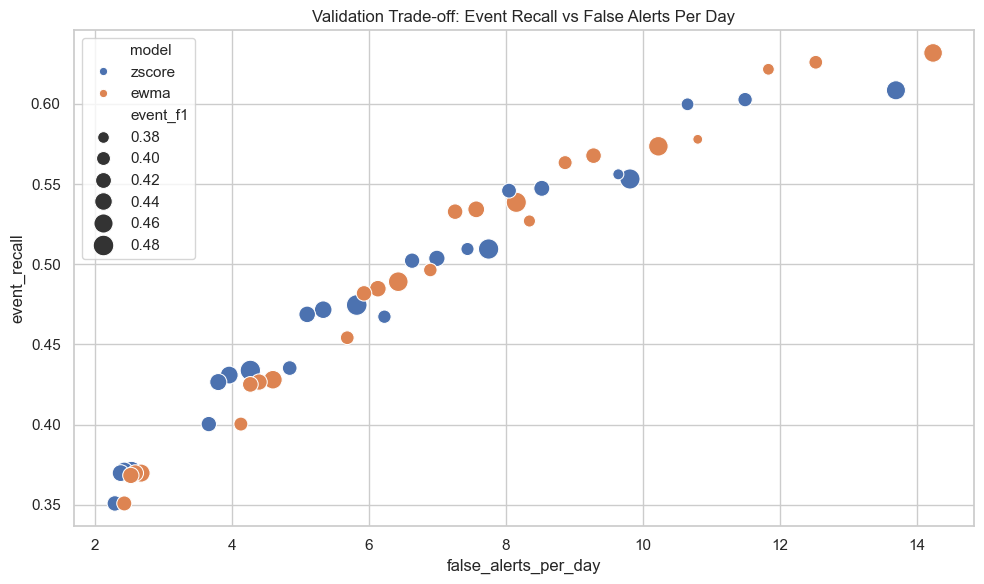

In [4]:
valid_times = valid["time"].to_numpy(dtype="datetime64[ns]")
valid_y = valid["pseudo_event"].astype(int).to_numpy()
valid_event_windows = build_event_windows(valid_times, valid_y, merge_gap_min=5, tolerance_min=10)

# target_alert_rate는 fit_train score 분포에서 상위 몇 %를 alert로 볼지 정하는 비율이다.
# 비율이 낮을수록 더 보수적이고, 높을수록 더 민감한 규칙이 된다.
target_alert_rates = [0.005, 0.0075, 0.010, 0.0125, 0.015, 0.020]
cooldown_candidates = [0, 5, 10, 20]

tuning_rows = []
for model_name, score_col in [("zscore", "zscore_score"), ("ewma", "ewma_score")]:
    fit_scores = master.loc[fit_train.index, score_col].dropna()

    for target_alert_rate in target_alert_rates:
        threshold = fit_scores.quantile(1 - target_alert_rate)
        base_pred = (master.loc[valid.index, score_col].to_numpy() >= threshold).astype(np.int8)

        for cooldown_min in cooldown_candidates:
            pred = apply_cooldown(valid_times, base_pred, cooldown_min)
            row = {
                "model": model_name,
                "target_alert_rate": target_alert_rate,
                "threshold": threshold,
                "cooldown_min": cooldown_min,
            }
            row.update(evaluate_rule(valid_times, valid_y, pred, valid_event_windows))
            tuning_rows.append(row)

tuning_grid = pd.DataFrame(tuning_rows)

# balanced objective는 event_f1을 높이되 false alert/day를 약하게 패널티 주는 방식이다.
tuning_grid["balanced_objective"] = (
    tuning_grid["event_f1"] - 0.005 * tuning_grid["false_alerts_per_day"]
)

tuning_grid = tuning_grid.sort_values(
    ["balanced_objective", "event_f1", "point_f1"],
    ascending=[False, False, False],
).reset_index(drop=True)

tuning_grid.to_csv(OUTPUT_DIR / "tuning_grid_validation.csv", index=False)

display(tuning_grid.head(15))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=tuning_grid,
    x="false_alerts_per_day",
    y="event_recall",
    hue="model",
    size="event_f1",
    sizes=(50, 220),
)
plt.title("Validation Trade-off: Event Recall vs False Alerts Per Day")
plt.tight_layout()
plt.show()


### 결과 해석
- validation에서 raw 기준 최고 `event_f1`은 **zscore / target_alert_rate=0.010 / cooldown=0** 조합으로 약 **0.480**이었습니다. 하지만 false alert/day가 약 **5.83**이라 운영 측면에서는 더 보수적인 대안도 함께 볼 필요가 있습니다.
- 같은 zscore 계열에서도 `0.0075 / cooldown=0`은 `event_f1≈0.476`, `false_alerts/day≈4.27`, `0.005 / cooldown=20`은 `event_f1≈0.416`, `false_alerts/day≈2.30`으로 명확한 trade-off를 보였습니다. 즉 threshold와 cooldown만으로도 경보 품질을 꽤 크게 조정할 수 있습니다.


## 3. Balanced / Conservative 규칙 선택

validation 결과를 바탕으로 서로 다른 운영 목적을 가진 두 가지 rule set을 고릅니다.


In [5]:
# balanced rule: event_f1과 false alert/day를 같이 본 objective가 가장 높은 조합
balanced_config = tuning_grid.sort_values(
    ["balanced_objective", "event_f1", "point_f1"],
    ascending=[False, False, False],
).iloc[0].copy()

# conservative rule: event_recall이 0.35 이상인 조합 중 false alert/day가 가장 낮은 조합
conservative_pool = tuning_grid[tuning_grid["event_recall"] >= 0.35].copy()
conservative_config = conservative_pool.sort_values(
    ["false_alerts_per_day", "event_f1", "point_f1"],
    ascending=[True, False, False],
).iloc[0].copy()

# baseline은 이전 노트북의 z-score 설정을 여기서 다시 참조하기 위한 기준점이다.
fit_event_rate = fit_train["pseudo_event"].mean()
baseline_threshold = master.loc[fit_train.index, "zscore_score"].dropna().quantile(1 - fit_event_rate)

selected_rule_configs = pd.DataFrame(
    [
        {
            "config_name": "baseline_zscore",
            "model": "zscore",
            "target_alert_rate": fit_event_rate,
            "threshold": baseline_threshold,
            "cooldown_min": 0,
        },
        {
            "config_name": "balanced_selected",
            "model": balanced_config["model"],
            "target_alert_rate": balanced_config["target_alert_rate"],
            "threshold": balanced_config["threshold"],
            "cooldown_min": balanced_config["cooldown_min"],
        },
        {
            "config_name": "conservative_selected",
            "model": conservative_config["model"],
            "target_alert_rate": conservative_config["target_alert_rate"],
            "threshold": conservative_config["threshold"],
            "cooldown_min": conservative_config["cooldown_min"],
        },
    ]
)

selected_rule_configs.to_csv(OUTPUT_DIR / "selected_rule_configs.csv", index=False)

display(selected_rule_configs)
display(balanced_config.to_frame().T)
display(conservative_config.to_frame().T)


,config_name,model,target_alert_rate,threshold,cooldown_min
0,baseline_zscore,zscore,0.013192,3.442974,0
1,balanced_selected,zscore,0.007500,3.959979,0
2,conservative_selected,zscore,0.005000,4.371867,20


,model,target_alert_rate,threshold,cooldown_min,point_precision,point_recall,point_f1,point_fpr,actual_alert_rate,pred_alert_count,true_event_count,event_precision,event_recall,event_f1,false_alerts_per_day,balanced_objective
0,zscore,0.007500,3.959979,0,0.288732,0.302583,0.295495,0.005238,0.007313,852,687,0.528169,0.433770,0.476338,4.273407,0.454971


,model,target_alert_rate,threshold,cooldown_min,point_precision,point_recall,point_f1,point_fpr,actual_alert_rate,pred_alert_count,true_event_count,event_precision,event_recall,event_f1,false_alerts_per_day,balanced_objective
17,zscore,0.005000,4.371867,20,0.346939,0.188192,0.244019,0.002489,0.003785,441,687,0.510204,0.350801,0.415747,2.296159,0.404266


### 결과 해석
- 자동 선택 결과 `balanced`는 **zscore / target_alert_rate=0.0075 / threshold≈3.960 / cooldown=0** 이었고, validation에서 `point_f1≈0.295`, `event_f1≈0.476`, `false_alerts/day≈4.27`을 보였습니다.
- `conservative`는 **zscore / 0.005 / threshold≈4.372 / cooldown=20** 으로 선택됐고, validation에서 `event_recall≈0.351`을 유지하면서 `false_alerts/day≈2.30`까지 낮췄습니다. 즉 한 모델 안에서도 운영 목적에 따라 규칙을 다르게 가져갈 수 있다는 점이 중요합니다.


## 4. Test 구간 비교

선택된 규칙을 한 번도 보지 않은 test 구간에 그대로 적용해 baseline 대비 개선 여부를 확인합니다.


,config_name,model,target_alert_rate,threshold,cooldown_min,point_precision,point_recall,point_f1,point_fpr,actual_alert_rate,pred_alert_count,true_event_count,event_precision,event_recall,event_f1,false_alerts_per_day
0,baseline_zscore,zscore,0.013192,3.442974,0,0.188386,0.302946,0.232310,0.009473,0.011587,2893,1530,0.399585,0.513072,0.449273,8.559227
1,balanced_selected,zscore,0.007500,3.959979,0,0.253545,0.248471,0.250983,0.005309,0.007061,1763,1530,0.480431,0.416340,0.446095,4.513674
2,conservative_selected,zscore,0.005000,4.371867,20,0.309224,0.163980,0.214312,0.002659,0.003821,954,1530,0.506289,0.344444,0.409972,2.320896


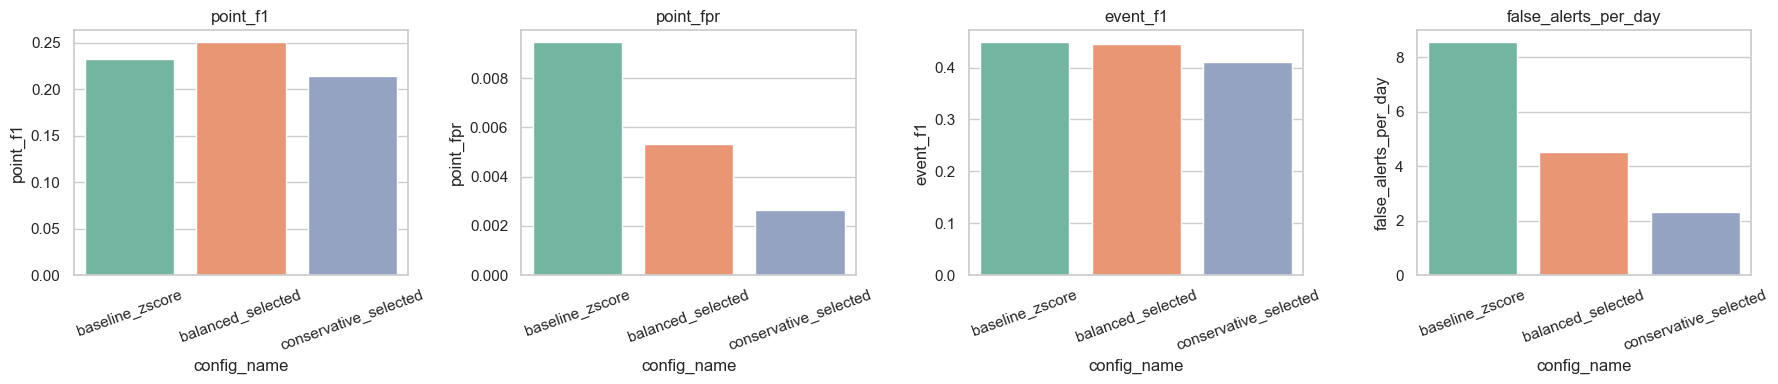

In [6]:
test_times = test["time"].to_numpy(dtype="datetime64[ns]")
test_y = test["pseudo_event"].astype(int).to_numpy()
test_event_windows = build_event_windows(test_times, test_y, merge_gap_min=5, tolerance_min=10)

def build_predictions_for_config(config_row):
    score_col = "zscore_score" if config_row["model"] == "zscore" else "ewma_score"
    base_pred = (
        master.loc[test.index, score_col].to_numpy() >= config_row["threshold"]
    ).astype(np.int8)
    return apply_cooldown(test_times, base_pred, int(config_row["cooldown_min"]))

test_comparison_rows = []
test_rule_predictions = test[["time", "raw_close", "raw_volume", "pseudo_event"]].copy()

for _, config_row in selected_rule_configs.iterrows():
    pred = build_predictions_for_config(config_row)
    pred_col = config_row["config_name"]
    test_rule_predictions[pred_col] = pred

    metrics_row = {
        "config_name": config_row["config_name"],
        "model": config_row["model"],
        "target_alert_rate": config_row["target_alert_rate"],
        "threshold": config_row["threshold"],
        "cooldown_min": config_row["cooldown_min"],
    }
    metrics_row.update(evaluate_rule(test_times, test_y, pred, test_event_windows))
    test_comparison_rows.append(metrics_row)

test_rule_comparison = pd.DataFrame(test_comparison_rows)
test_rule_predictions.to_csv(OUTPUT_DIR / "test_rule_predictions.csv", index=False)
test_rule_comparison.to_csv(OUTPUT_DIR / "test_rule_comparison.csv", index=False)

display(test_rule_comparison)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metric_cols = ["point_f1", "point_fpr", "event_f1", "false_alerts_per_day"]
for ax, metric_name in zip(axes, metric_cols):
    sns.barplot(data=test_rule_comparison, x="config_name", y=metric_name, ax=ax, palette="Set2")
    ax.set_title(metric_name)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 결과 해석
- test 기준 `baseline_zscore`는 `point_f1≈0.232`, `event_f1≈0.449`, `false_alerts/day≈8.56`였습니다. `balanced_selected`는 `point_f1≈0.251`로 오히려 좋아지면서 `point_fpr≈0.00531`, `false_alerts/day≈4.51`로 baseline 대비 경보 부담을 거의 절반 수준으로 줄였습니다.
- `conservative_selected`는 `point_precision≈0.309`, `point_fpr≈0.00266`, `false_alerts/day≈2.32`로 가장 보수적이지만 `event_f1≈0.410`까지 내려갑니다. 인사이트는 '무조건 F1 최대'보다, 운영 목적에 따라 `balanced`와 `conservative` 두 안을 분리해 제안하는 편이 더 실무적이라는 점입니다.


## 5. 이벤트 창에서 규칙 차이 보기

같은 이벤트라도 rule이 다르면 경보 개수와 시점이 어떻게 바뀌는지 시각적으로 확인합니다.


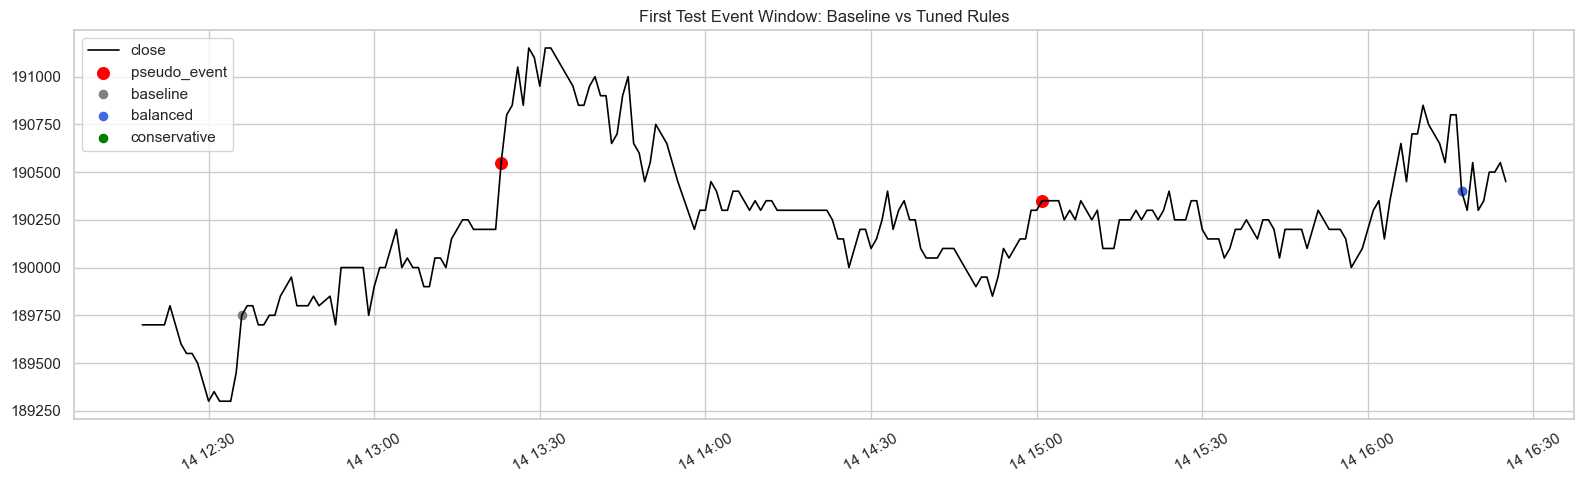

,time,raw_close,pseudo_event,baseline_zscore,balanced_selected,conservative_selected
582602,2019-04-14 12:18:00,189700,0.000000,0,0,0
582603,2019-04-14 12:19:00,189700,0.000000,0,0,0
582604,2019-04-14 12:20:00,189700,0.000000,0,0,0
582605,2019-04-14 12:21:00,189700,0.000000,0,0,0
582606,2019-04-14 12:22:00,189700,0.000000,0,0,0
582607,2019-04-14 12:23:00,189800,0.000000,0,0,0
582608,2019-04-14 12:24:00,189700,0.000000,0,0,0
582609,2019-04-14 12:25:00,189600,0.000000,0,0,0
582610,2019-04-14 12:26:00,189550,0.000000,0,0,0
582611,2019-04-14 12:27:00,189550,0.000000,0,0,0


first_test_event_time: 2019-04-14 13:23:00
window alert counts: {'pseudo_event': 2.0, 'baseline_zscore': 2.0, 'balanced_selected': 1.0, 'conservative_selected': 0.0}


In [7]:
# test 구간 첫 pseudo event를 중심으로 앞 60분, 뒤 180분을 잘라본다.
first_test_event_idx = test.index[test["pseudo_event"] == 1][0]
window_start = max(0, first_test_event_idx - 60)
window_end = min(len(master) - 1, first_test_event_idx + 180)

rule_window_sample = master.loc[
    window_start:window_end,
    ["time", "raw_close", "pseudo_event"],
].copy()

for config_name in selected_rule_configs["config_name"]:
    rule_window_sample[config_name] = test_rule_predictions.loc[
        rule_window_sample.index.intersection(test_rule_predictions.index),
        config_name,
    ]

plot_window = rule_window_sample.fillna(0)
rule_window_sample.to_csv(OUTPUT_DIR / "rule_window_sample.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(plot_window["time"], plot_window["raw_close"], color="black", linewidth=1.2, label="close")

event_points = plot_window[plot_window["pseudo_event"] == 1]
baseline_points = plot_window[plot_window["baseline_zscore"] == 1]
balanced_points = plot_window[plot_window["balanced_selected"] == 1]
conservative_points = plot_window[plot_window["conservative_selected"] == 1]

ax.scatter(event_points["time"], event_points["raw_close"], color="red", s=70, label="pseudo_event")
ax.scatter(baseline_points["time"], baseline_points["raw_close"], color="gray", s=35, label="baseline")
ax.scatter(balanced_points["time"], balanced_points["raw_close"], color="royalblue", s=35, label="balanced")
ax.scatter(conservative_points["time"], conservative_points["raw_close"], color="green", s=35, label="conservative")

ax.set_title("First Test Event Window: Baseline vs Tuned Rules")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

display(rule_window_sample.head(20))
print("first_test_event_time:", master.loc[first_test_event_idx, "time"])
print(
    "window alert counts:",
    plot_window[["pseudo_event", "baseline_zscore", "balanced_selected", "conservative_selected"]].sum().to_dict(),
)


### 결과 해석
- 첫 test 이벤트는 **2019-04-14 13:23:00** 부근에 있고, 이 창에서 `pseudo_event=2개`, `baseline=2개`, `balanced=1개`, `conservative=0개`의 경보가 나왔습니다. 즉 balanced는 중복 경보를 줄이면서 핵심 이벤트를 한 번은 잡았고, conservative는 이 정도 약한 이벤트는 과감히 놓치는 대신 경보 부담을 줄입니다.
- 문제는 false alarm을 줄일수록 일부 이벤트 miss가 늘어난다는 점입니다. 원인은 threshold 상승과 긴 cooldown으로 민감도가 낮아지기 때문이며, 해결방안은 운영 목적에 따라 `탐지형 룰`과 `보수형 룰`을 분리 제안하는 것입니다.


## 6. Next Step

1. 발표/포트폴리오에서는 `balanced rule`을 기본안으로, `conservative rule`을 운영안 옵션으로 함께 제시합니다.
2. 다음 단계에서는 `05_monitoring_story_and_dashboard.ipynb`에서 경보 대시보드 시나리오와 반도체 공정 모니터링 언어로의 번역을 정리합니다.
3. 면접 대비용으로는 `왜 validation에서 threshold를 고르고 test에 그대로 적용했는가`, `왜 false_alerts/day를 같이 봤는가`를 답변 포인트로 정리하면 좋습니다.
